# 06 Association Rules (Apriori)

This notebook performs market-basket analysis to find item combinations and recommendation rules.

**Input:**
- `outputs/transactions_cleaned.csv` (from Notebook 01)

**Output:**
- `outputs/frequent_itemsets.csv`
- `outputs/association_rules_all.csv`
- `outputs/association_rules_top.csv`

In [ ]:
from pathlib import Path
import json
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [ ]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"
INPUT_PATH = OUTPUT_DIR / "transactions_cleaned.csv"

print("Input exists:", INPUT_PATH.exists())

Input exists: True


In [ ]:
df = pd.read_csv(INPUT_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1000, 10)


,transaction_id,customer_id,customer_age,customer_gender,date,day_of_week,time_slot,total_amount,payment_method,items_json
0,TXN-2024-0000001,CUST1001,38,M,2024-01-07 19:17:00,Sun,Lunch,34,Cash,"[{""itemName"":""Lassi"",""quantity"":1,""price"":30,""..."
1,TXN-2024-0000002,CUST1002,36,F,2024-01-09 08:05:00,Tue,Lunch,142,Cash,"[{""itemName"":""Tea"",""quantity"":1,""price"":15,""ca..."
2,TXN-2024-0000003,CUST1003,42,M,2024-06-27 14:21:00,Thu,Lunch,105,Wallet,"[{""itemName"":""Veg Biryani"",""quantity"":1,""price..."
3,TXN-2024-0000004,CUST1004,21,F,2024-03-29 17:16:00,Fri,Dinner,85,UPI,"[{""itemName"":""Maggi"",""quantity"":1,""price"":40,""..."
4,TXN-2024-0000005,CUST1005,36,M,2024-06-29 09:02:00,Sat,Snacks,205,Wallet,"[{""itemName"":""Cold Coffee"",""quantity"":2,""price..."


In [ ]:
required = ["transaction_id", "items_json"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for association rules: {missing}")

work = df[required].dropna().copy()
print("Rows with basket data:", len(work))

Rows with basket data: 1000


In [ ]:
def parse_items(raw):
    if pd.isna(raw):
        return []

    val = raw
    if isinstance(raw, str):
        # Try JSON first, then Python literal fallback
        try:
            val = json.loads(raw)
        except Exception:
            try:
                val = ast.literal_eval(raw)
            except Exception:
                return []

    names = []
    if isinstance(val, list):
        for it in val:
            if isinstance(it, dict):
                nm = it.get("itemName") or it.get("name")
                if nm:
                    names.append(str(nm))
            elif isinstance(it, str):
                names.append(it)
    return sorted(list(set(names)))

In [ ]:
work["items"] = work["items_json"].apply(parse_items)
work = work[work["items"].map(len) > 0].copy()

print("Transactions with valid parsed baskets:", len(work))
work.head()

Transactions with valid parsed baskets: 1000


,transaction_id,items_json,items
0,TXN-2024-0000001,"[{""itemName"":""Lassi"",""quantity"":1,""price"":30,""...",[Lassi]
1,TXN-2024-0000002,"[{""itemName"":""Tea"",""quantity"":1,""price"":15,""ca...","[Rajma Chawal, Sandwich, Tea]"
2,TXN-2024-0000003,"[{""itemName"":""Veg Biryani"",""quantity"":1,""price...",[Veg Biryani]
3,TXN-2024-0000004,"[{""itemName"":""Maggi"",""quantity"":1,""price"":40,""...","[Lassi, Maggi, Samosa]"
4,TXN-2024-0000005,"[{""itemName"":""Cold Coffee"",""quantity"":2,""price...","[Cold Coffee, Paneer Curry+Roti]"


In [ ]:
# Build basket matrix (transaction x item)
exploded = work[["transaction_id", "items"]].explode("items")
exploded = exploded.dropna(subset=["items"]).reset_index(drop=True)

basket_matrix = pd.crosstab(exploded["transaction_id"], exploded["items"]).astype(bool)
print("Basket matrix shape:", basket_matrix.shape)
basket_matrix.head()

Basket matrix shape: (1000, 18)


items,Brownie,Chicken Biryani,Chicken Curry+Rice,Chole Bhature,Coffee,Cold Coffee,Dal Rice,Fruit Bowl,Ice Cream,Lassi,Lemonade,Maggi,Paneer Curry+Roti,Rajma Chawal,Samosa,Sandwich,Tea,Veg Biryani
transaction_id,,,,,,,,,,,,,,,,,,
TXN-2024-0000001,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
TXN-2024-0000002,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False
TXN-2024-0000003,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
TXN-2024-0000004,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False
TXN-2024-0000005,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
# Frequent itemsets
min_support = 0.02
freq = apriori(basket_matrix, min_support=min_support, use_colnames=True)
freq["itemset_size"] = freq["itemsets"].apply(len)
freq = freq.sort_values(["support", "itemset_size"], ascending=[False, False])

print("Frequent itemsets found:", len(freq))
freq.head(15)

Frequent itemsets found: 18


,support,itemsets,itemset_size
0,0.128,frozenset({Brownie}),1
9,0.126,frozenset({Lassi}),1
10,0.124,frozenset({Lemonade}),1
11,0.122,frozenset({Maggi}),1
15,0.120,frozenset({Sandwich}),1
8,0.119,frozenset({Ice Cream}),1
7,0.118,frozenset({Fruit Bowl}),1
17,0.118,frozenset({Veg Biryani}),1
2,0.115,frozenset({Chicken Curry+Rice}),1
13,0.113,frozenset({Rajma Chawal}),1


In [ ]:
# Generate association rules
rules = association_rules(freq, metric="lift", min_threshold=1.0)

if len(rules) == 0:
    print("No rules found. Try lower min_support or min_threshold.")
else:
    rules = rules.sort_values(["lift", "confidence", "support"], ascending=False)

rules.head(15) if len(rules) else rules

No rules found. Try lower min_support or min_threshold.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [ ]:
# Business-friendly filtered rules
if len(rules):
    top_rules = rules[(rules["confidence"] >= 0.3) & (rules["lift"] >= 1.1)].copy()
    top_rules = top_rules.sort_values(["lift", "confidence"], ascending=False)
else:
    top_rules = rules.copy()

print("Top filtered rules:", len(top_rules))
top_rules.head(20)

Top filtered rules: 0


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


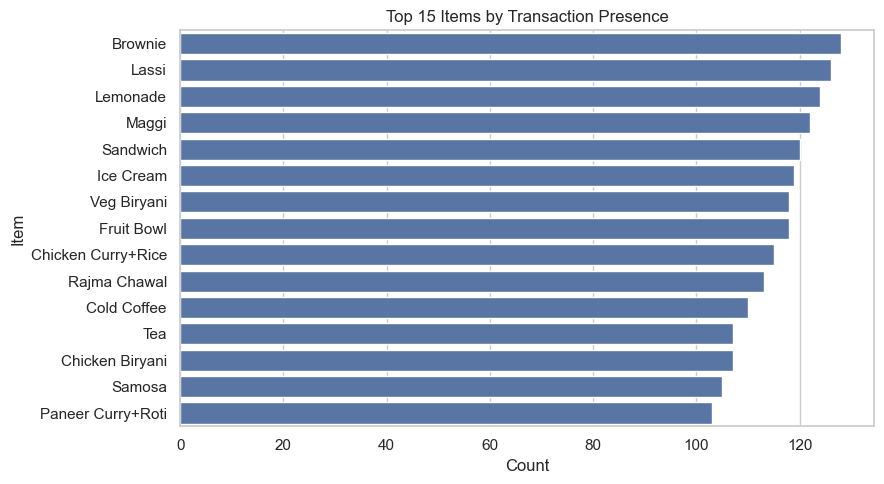

In [ ]:
# Visuals for top items and top rules
item_pop = exploded["items"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=item_pop.values, y=item_pop.index)
plt.title("Top 15 Items by Transaction Presence")
plt.xlabel("Count")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

if len(top_rules):
    plot_rules = top_rules.head(15).copy()
    plot_rules["rule"] = plot_rules.apply(
        lambda r: f"{', '.join(list(r['antecedents']))} -> {', '.join(list(r['consequents']))}",
        axis=1,
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_rules, x="lift", y="rule")
    plt.title("Top 15 Rules by Lift")
    plt.tight_layout()
    plt.show()

In [ ]:
# Save outputs
freq_out = OUTPUT_DIR / "frequent_itemsets.csv"
rules_all_out = OUTPUT_DIR / "association_rules_all.csv"
rules_top_out = OUTPUT_DIR / "association_rules_top.csv"

freq_save = freq.copy()
freq_save["itemsets"] = freq_save["itemsets"].apply(lambda x: "|".join(sorted(list(x))))
freq_save.to_csv(freq_out, index=False)

if len(rules):
    rules_save = rules.copy()
    rules_save["antecedents"] = rules_save["antecedents"].apply(lambda x: "|".join(sorted(list(x))))
    rules_save["consequents"] = rules_save["consequents"].apply(lambda x: "|".join(sorted(list(x))))
    rules_save.to_csv(rules_all_out, index=False)
else:
    pd.DataFrame().to_csv(rules_all_out, index=False)

if len(top_rules):
    top_save = top_rules.copy()
    top_save["antecedents"] = top_save["antecedents"].apply(lambda x: "|".join(sorted(list(x))))
    top_save["consequents"] = top_save["consequents"].apply(lambda x: "|".join(sorted(list(x))))
    top_save.to_csv(rules_top_out, index=False)
else:
    pd.DataFrame().to_csv(rules_top_out, index=False)

print("Saved:")
print("-", freq_out)
print("-", rules_all_out)
print("-", rules_top_out)

Saved:
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\frequent_itemsets.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\association_rules_all.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\association_rules_top.csv


## Recommendation Examples

Use top rules to generate suggestions, e.g.:
- If antecedent is in cart, recommend consequent.
- Prioritize rules with high confidence and lift.
- Use support to avoid very rare combinations.

## Next Notebook

Continue with `07_export_results_to_supabase.ipynb` to consolidate all outputs into one final local analytics package (CSV/JSON) for dashboard/report use.